In [2]:
import pandas as pd


In [3]:
df=pd.read_csv('/content/all_lyrics.csv')

In [4]:
df.head(2)

,song,artist,type,lyrics
0,Stairway to Heaven,Led Zeppelin,rock,Stairway to Heaven Lyrics[Intro]\n\n[Verse 1]\...
1,Hey Jude,Beatles,rock,Hey Jude Lyrics[Verse 1: Paul McCartney]\nHey ...


In [5]:
df.dtypes

,0
song,object
artist,object
type,object
lyrics,object


In [6]:
df.drop(['type','song','artist'],axis=1,inplace=True)

In [12]:
import re
df=df.astype(str)
df=df.apply((lambda x: re.sub('[^A-Za-z]', ' ', x)))

In [13]:
df.head(2)

,lyrics
0,Stairway to Heaven Lyrics Intro Verse Th...
1,Hey Jude Lyrics Verse Paul McCartney Hey J...


In [8]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [9]:
token=Tokenizer(num_words=5000,oov_token='<OOV>')


In [10]:
df.shape

(4000, 1)

In [11]:
df = df['lyrics'].iloc[:700]


In [63]:
df['lyrics'].shape

TypeError: string indices must be integers, not 'str'

In [14]:

token.fit_on_texts(df)

In [15]:
from keras.preprocessing import sequence
lyrics_sequences = token.texts_to_sequences(df)

In [16]:
lyrics_sequences[0] # Print first 5 sequences to demonstrate

[3250,
 4,
 432,
 95,
 253,
 28,
 61,
 11,
 7,
 300,
 71,
 11,
 348,
 22,
 12,
 1,
 23,
 554,
 6,
 27,
 11,
 2716,
 7,
 3250,
 4,
 432,
 52,
 27,
 547,
 61,
 27,
 452,
 67,
 2,
 4758,
 69,
 22,
 1330,
 19,
 7,
 408,
 27,
 36,
 64,
 44,
 27,
 339,
 18,
 104,
 104,
 6,
 27,
 11,
 2716,
 7,
 3250,
 4,
 432,
 61,
 11,
 7,
 682,
 16,
 2,
 548,
 29,
 27,
 567,
 4,
 26,
 348,
 151,
 5,
 48,
 542,
 442,
 58,
 186,
 1,
 9,
 7,
 1382,
 17,
 2,
 1,
 61,
 11,
 7,
 1,
 71,
 1483,
 542,
 22,
 8,
 102,
 1235,
 69,
 1,
 32,
 104,
 10,
 400,
 13,
 474,
 104,
 400,
 13,
 474,
 28,
 61,
 11,
 7,
 303,
 3,
 64,
 52,
 3,
 130,
 4,
 2,
 742,
 6,
 14,
 775,
 23,
 743,
 18,
 1053,
 9,
 14,
 1235,
 3,
 58,
 261,
 1331,
 8,
 878,
 133,
 2,
 961,
 6,
 2,
 1194,
 8,
 156,
 71,
 223,
 269,
 32,
 104,
 10,
 400,
 13,
 474,
 104,
 144,
 400,
 13,
 474,
 28,
 6,
 10,
 11,
 3618,
 12,
 531,
 67,
 25,
 22,
 231,
 2,
 1383,
 126,
 2,
 1,
 91,
 805,
 115,
 4,
 701,
 6,
 7,
 149,
 85,
 91,
 1195,
 18,
 156,
 71,
 223,
 10

In [17]:
print(len((token.word_index)))

22462


In [46]:
MAX_LEN = 40
input_sequences = []
for sequence in lyrics_sequences:
    sequence = sequence[:MAX_LEN]
    for i in range(1, len(sequence)):
        input_sequences.append(sequence[:i+1])

In [47]:
len(input_sequences)

26703

In [48]:
max(len(x) for x in input_sequences)

40

In [49]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [50]:
pad_sequences=pad_sequences(input_sequences,maxlen=40,padding='pre')

In [51]:
pad_sequences[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0, 3250,    4], dtype=int32)

In [166]:
from keras.utils import to_categorical
import numpy as np

In [170]:
# create predictors and label
X = pad_sequences[:,:-1]
labels = pad_sequences[:,-1]
y = tf.keras.utils.to_categorical(labels, num_classes=5000)

TypeError: 'function' object is not subscriptable

In [172]:
X

array([[   0,    0,    0, ...,    0,    0, 3250],
       [   0,    0,    0, ...,    0, 3250,    4],
       [   0,    0,    0, ..., 3250,    4,  432],
       ...,
       [   0,    0, 2715, ...,   78,   13,    9],
       [   0, 2715,   72, ...,   13,    9,   78],
       [2715,   72, 4385, ...,    9,   78,   13]], dtype=int32)

In [87]:
import tensorflow as tf

In [99]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
model = Sequential()
model.add(InputLayer(shape=(39,))) # Changed input_shape to shape
model.add(Embedding(input_dim=5000, output_dim=100)) # No input_shape here
model.add(Bidirectional(LSTM(250)))
model.add(Bidirectional(LSTM(64))
model.add(Dense(5000, activation='softmax'))

In [103]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 39, 100)        │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 500)            │       702,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5000)           │     2,505,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,121,002 (42.42 MB)

 Trainable params: 3,707,000 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,414,002 (28.28 MB)

In [104]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [105]:
history = model.fit(X, y, epochs=30,)


Epoch 1/30
835/835 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.2493 - loss: 3.8962
Epoch 2/30
835/835 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.2878 - loss: 3.4908
Epoch 3/30
835/835 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.3380 - loss: 3.0347
Epoch 4/30
835/835 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4181 - loss: 2.5885
Epoch 5/30
835/835 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4991 - loss: 2.2297
Epoch 6/30
835/835 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5735 - loss: 1.8779
Epoch 7/30
835/835 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.6404 - loss: 1.5969
Epoch 8/30
835/835 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7074 - loss: 1.3227
Epoch 9/30
835/835 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7717 - loss: 1.0720
Epoch 10/30
835/835 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8216 - loss: 0.8835
Epoch 11/30
835/835 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8603 - loss: 0.7139
Epoch 12/30
835/835 ━━━━━━━━━━━

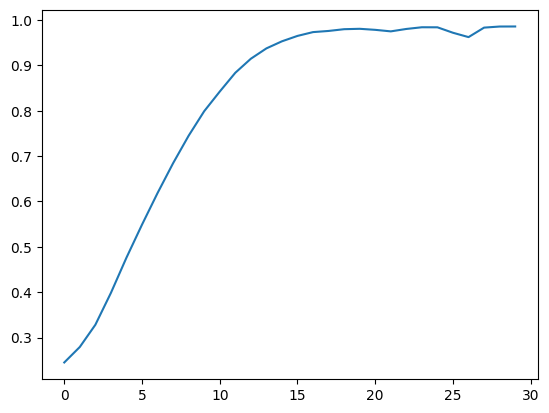

In [106]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])

In [154]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def complete_this_for_me(seed_text, next_words):
    output_text = seed_text

    for _ in range(next_words):
        # Convert current seed text to sequence of integers
        token_list = token.texts_to_sequences([output_text])[0]

        # Pad sequence to match model input
        token_list = pad_sequences([token_list], maxlen=40, padding='pre')

        # Predict next word probabilities
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(predicted_probs, axis=-1)[0]  # most likely word

        # Map predicted index back to word
        for word, index in token.word_index.items():
            if index == predicted_index:
                output_word = word
                break  # stop loop after finding word

        # Append predicted word to the seed
        output_text += " " + output_word

    return output_text

In [157]:
complete_this_for_me("There a lady who's sure",100)

"There a lady who's sure s no mind lyricswell a little bit of rock n roll you think the <OOV> is the night <OOV> is the <OOV> and <OOV> on the <OOV> playin <OOV> it s <OOV> into the <OOV> will <OOV> in <OOV> little old <OOV> feels the <OOV> and <OOV> you ve <OOV> to run don t you feel the world in a house of the <OOV> verse the <OOV> and the beat when the cos <OOV> out and rock on the <OOV> when <OOV> s <OOV> to the <OOV> i miss <OOV> to the world and a <OOV> he <OOV> and the"